In [1]:
from scipy.optimize import minimize
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats.distributions import norm
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.base.datetools import dates_from_str
from statsmodels.tsa.api import VARMAX
import statsmodels.api as sm
import pandas as pd
from scipy.linalg import inv

In [23]:
# Load in data
df = pd.read_csv("cleaned_produce.csv")

carrots = df[df["productname"] == "Thompson Grapes"]

In [24]:
print(carrots.columns)

Index(['Unnamed: 0', 'productname', 'date', 'farmprice', 'atlantaretail',
       'chicagoretail', 'losangelesretail', 'newyorkretail', 'averageretail'],
      dtype='object')


In [ ]:
# Create DatetimeIndex
carrots.index = pd.DatetimeIndex(carrots["date"])
# Select columns used in prediction
df = carrots[['atlantaretail', 'losangelesretail', 'newyorkretail', 'chicagoretail']]

# Initialize and fit model
mod = VARMAX(df)
mod = mod.fit(maxiter=1000, disp=False)

# Predict the price of aluminium and copper until 1985
print(df.index[0], df.index[-1])

/home/xzaitzeff/documents/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/home/xzaitzeff/documents/.venv/lib/python3.10/site-packages/statsmodels/tsa/statespace/varmax.py:326: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  endog = np.require(endog.fillna(method='backfill'), requirements="W")


1999-10-24 00:00:00 2019-05-19 00:00:00


/home/xzaitzeff/documents/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/home/xzaitzeff/documents/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


Text(0.5, 0.98, 'VARMA Predictions for Carrot Prices across cities')

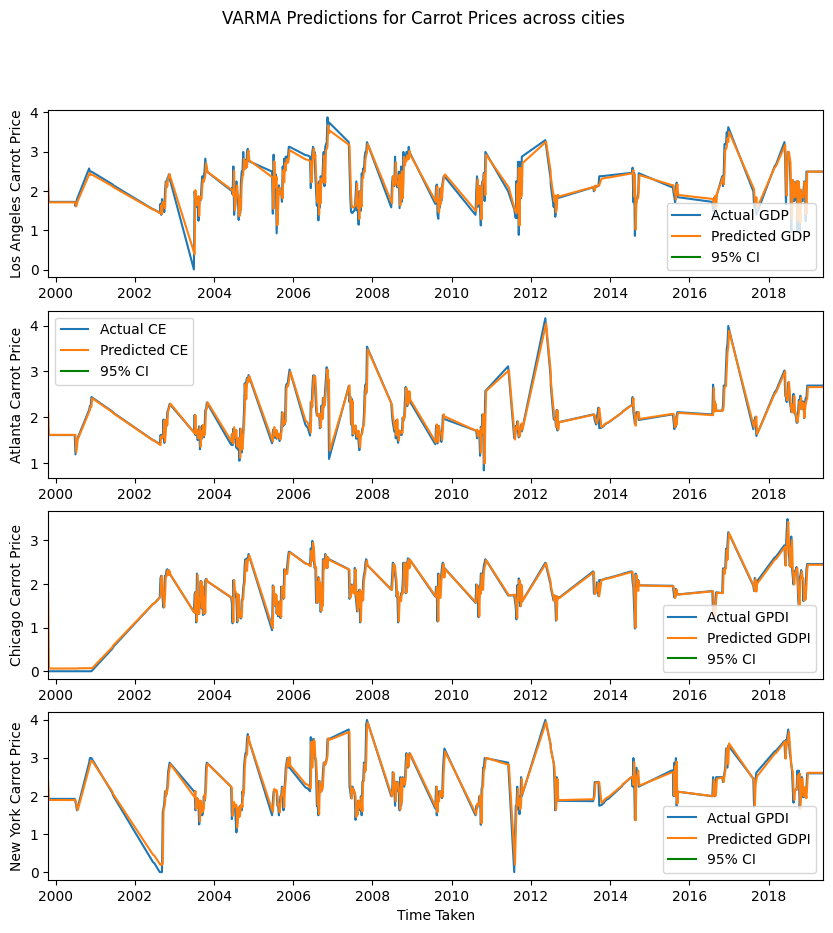

In [ ]:
pred = mod.predict(df.index[0], df.index[-1])
# Get confidence intervals
forecast_obj = mod.get_forecast()
all_CI = forecast_obj.conf_int(alpha=0.05)

# Plot predictions against true measures of the economy
fig, ax = plt.subplots(4, 1, figsize=(10, 10))
ax[0].plot(df['losangelesretail'], label='Actual GDP')
ax[0].plot(pred["losangelesretail"], label="Predicted GDP")
ax[0].plot(all_CI["lower losangelesretail"], c="g", label="95% CI")
ax[0].plot(all_CI["upper losangelesretail"], c="g")
ax[0].set_ylabel("Los Angeles Carrot Price")
ax[0].set_xlim(df['losangelesretail'].index[0], df['losangelesretail'].index[-1])

ax[1].plot(df['atlantaretail'], label='Actual CE')
ax[1].plot(pred['atlantaretail'], label="Predicted CE")
ax[1].plot(all_CI["lower atlantaretail"], c="g", label="95% CI")
ax[1].plot(all_CI["upper atlantaretail"], c="g")
ax[1].set_ylabel("Atlanta Carrot Price")
ax[1].set_xlim(df['atlantaretail'].index[0], df['atlantaretail'].index[-1])

ax[2].plot(df['chicagoretail'], label='Actual GPDI')
ax[2].plot(pred["chicagoretail"], label="Predicted GDPI")
ax[2].plot(all_CI["lower chicagoretail"], c="g", label="95% CI")
ax[2].plot(all_CI["upper chicagoretail"], c="g")
ax[2].set_ylabel("Chicago Carrot Price")
ax[2].set_xlim(df['chicagoretail'].index[0], df['chicagoretail'].index[-1])

ax[3].plot(df['newyorkretail'], label='Actual GPDI')
ax[3].plot(pred['newyorkretail'], label="Predicted GDPI")
ax[3].plot(all_CI["lower newyorkretail"], c="g", label="95% CI")
ax[3].plot(all_CI["upper newyorkretail"], c="g")
ax[3].set_xlim(df['newyorkretail'].index[0], df['newyorkretail'].index[-1])
ax[3].set_ylabel("New York Carrot Price")
ax[3].set_xlabel("Time Taken")

ax[0].legend()
ax[1].legend()
ax[2].legend()
ax[3].legend()

plt.suptitle('VARMA Predictions for Carrot Prices across cities')

In [17]:
import pandas as pd
from statsmodels.tsa.api import VARMAX
import statsmodels.api as sm
from matplotlib import pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
import numpy as np


In [ ]:
# look at two similar fruits
fruit = pd.read_csv("cleaned_produce.csv")
df = fruit.pivot_table(index="date", columns="productname", values="averageretail")
y1, y2 = 'Nectarines', 'Peaches'
data = df[[y1, y2]]

mod = VARMAX(data)
mod = mod.fit(maxiter=1000, disp=False)

# pred = mod.predict(df.index[0], df.index[-1])   # in sample predictions
# plt.plot(df.index, pred[y1], label=f'predicted {y1}')
# plt.plot(df.index, data[y1], label=f'actual {y1}')

# plt.plot(df.index, pred[y2], label=f'predicted {y2}')
# plt.plot(df.index, data[y2], label=f'actual {y2}')

# plt.legend()


/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/base/optimizer.py:18: FutureWarning: Keyword arguments have been passed to the optimizer that have no effect. The list of allowed keyword arguments for method lbfgs is: m, pgtol, factr, maxfun, epsilon, approx_grad, bounds, loglike_and_score, iprint. The list of unsupported keyword arguments passed include: maxier. After release 0.14, this will raise.
  warnings.warn(


/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information

VARMAX prediction on nectarines MSE: 0.3084462836661755
ARMA prediction on nectarines MSE: 0.3332713885359178


/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:836: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/josieallred/.venvs/ACME/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:836: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


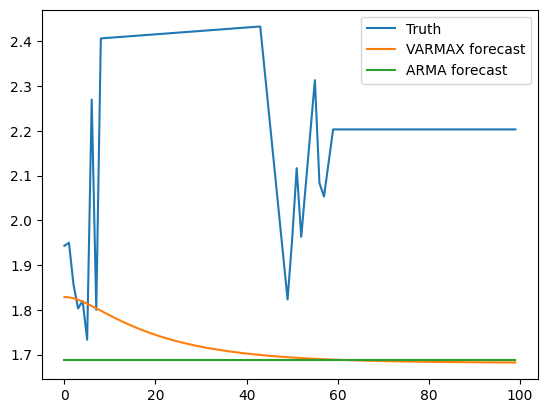

In [40]:
# does model with both predict better than model with just one
n_steps = 100
train = data.iloc[:-n_steps]
test = data.iloc[-n_steps:]

# build varmax 
var_model = VARMAX(train).fit(disp=False)   # specify order?
var_forecast = np.array(var_model.forecast(steps=n_steps)[y1])

# build regular
uni_model = ARIMA(train[y1]).fit()    # specify order?
uni_forecast = np.array(uni_model.forecast(steps=n_steps))

# determine and compare errors
y_hat = np.array(test[y1])
var_error = np.mean((var_forecast - y_hat)**2)
uni_error = np.mean((uni_forecast - y_hat)**2)

print(f'VARMAX prediction on nectarines MSE: {var_error}')
print(f'ARMA prediction on nectarines MSE: {uni_error}')

# plt.plot(train[y1].index, train[y1])
plt.plot(y_hat, label='Truth')
plt.plot(var_forecast, label='VARMAX forecast')
plt.plot(uni_forecast, label='ARMA forecast')
plt.legend()

next steps:
- use jeremy's prediction method
- plot
- try with other fruits